Check Scene Objects:
Objects in scene: ['no-name-1', 'no-name-2', 'Plane']
Radio Materials in scene: ['itu-ceiling_board', 'itu-concrete', 'itu-medium_dry_ground']
tx_tilt_deg = 0°


<Figure size 800x1000 with 0 Axes>

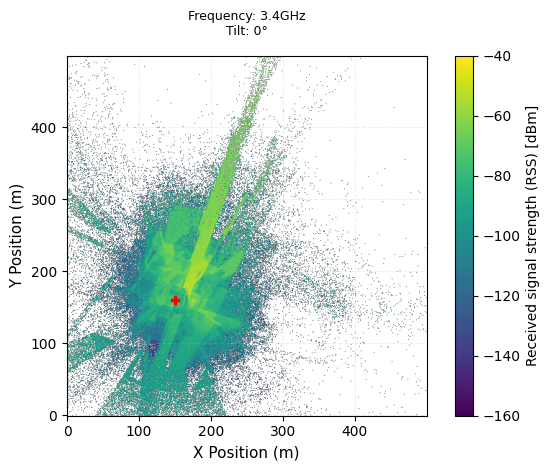

tx_tilt_deg = 15°


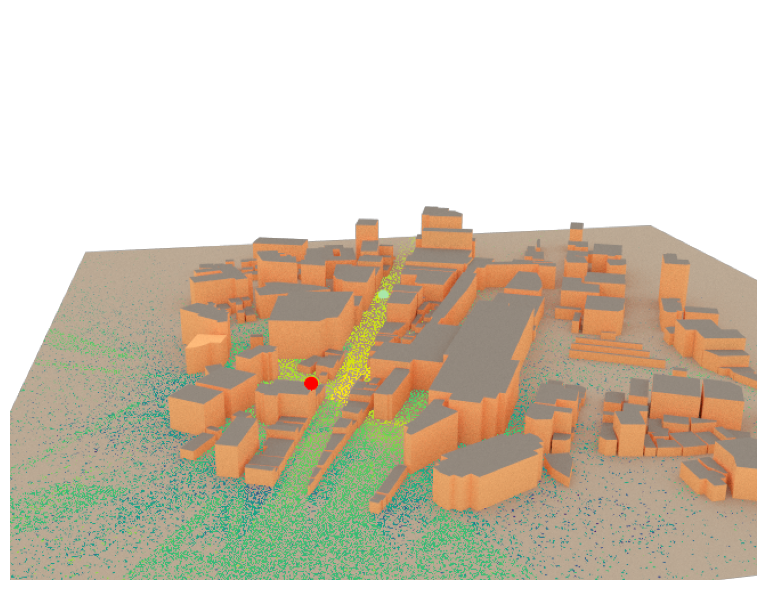

<Figure size 800x1000 with 0 Axes>

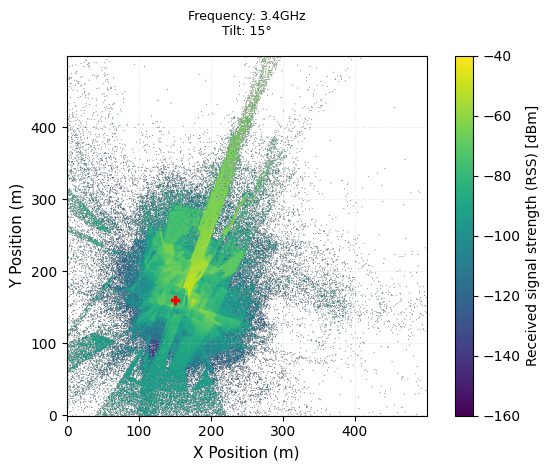

tx_tilt_deg = 30°


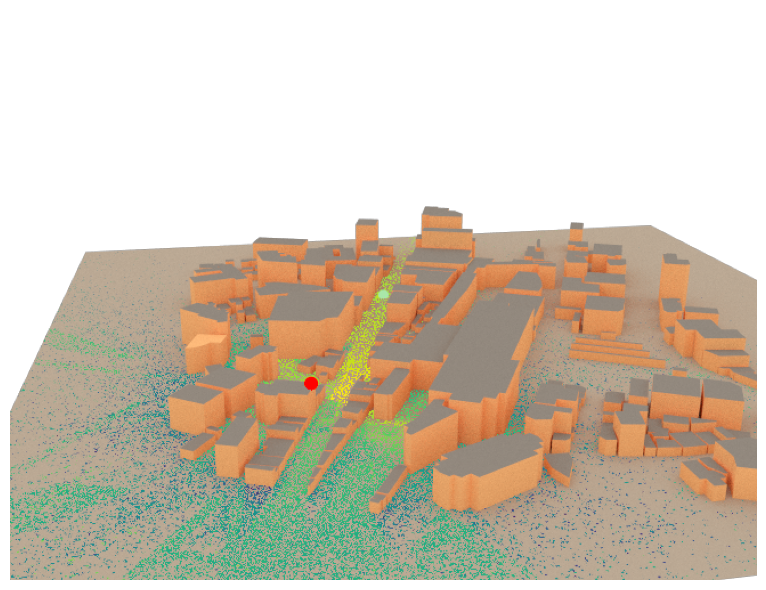

<Figure size 800x1000 with 0 Axes>

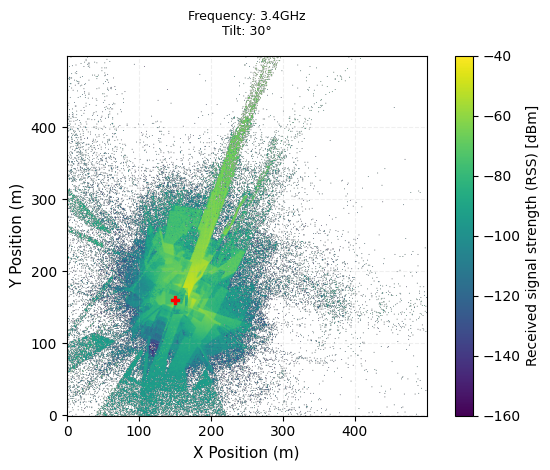

tx_tilt_deg = 45°


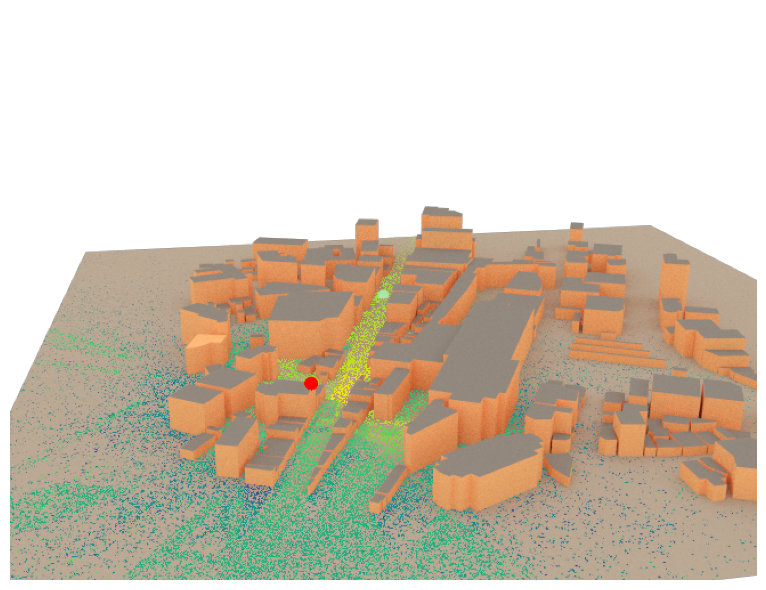

<Figure size 800x1000 with 0 Axes>

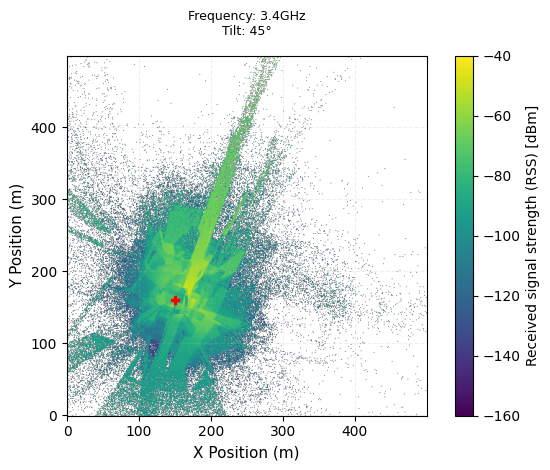

tx_tilt_deg = 60°


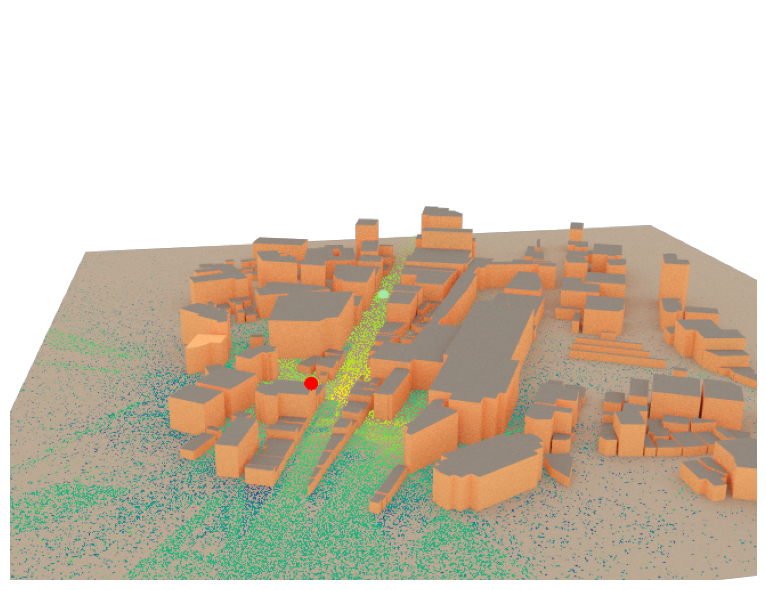

<Figure size 800x1000 with 0 Axes>

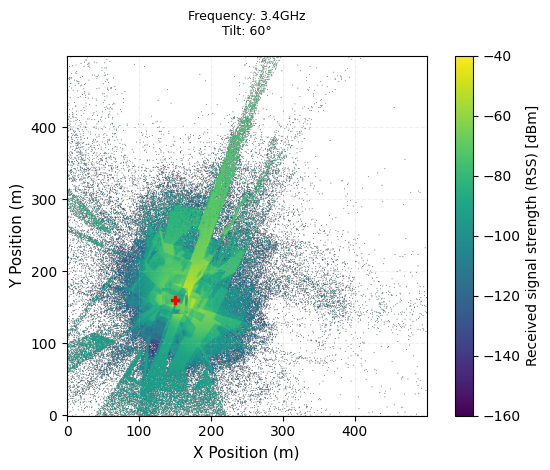

tx_tilt_deg = 75°


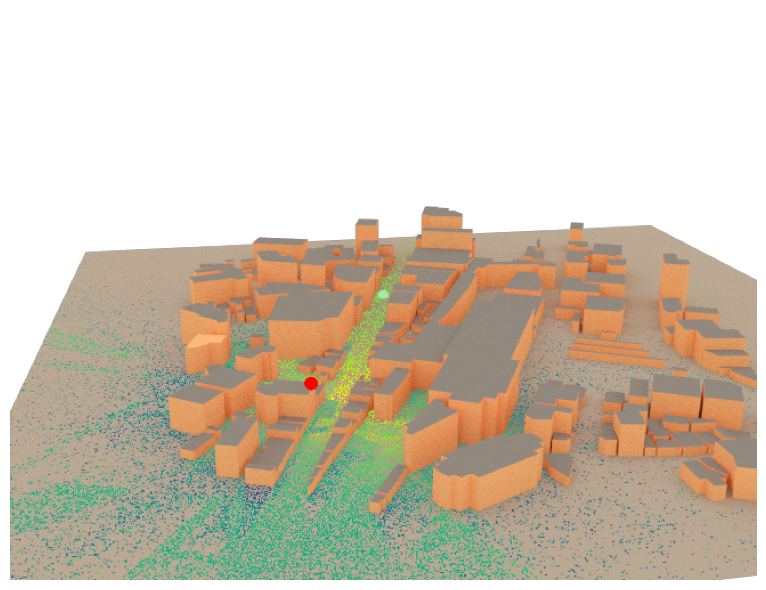

<Figure size 800x1000 with 0 Axes>

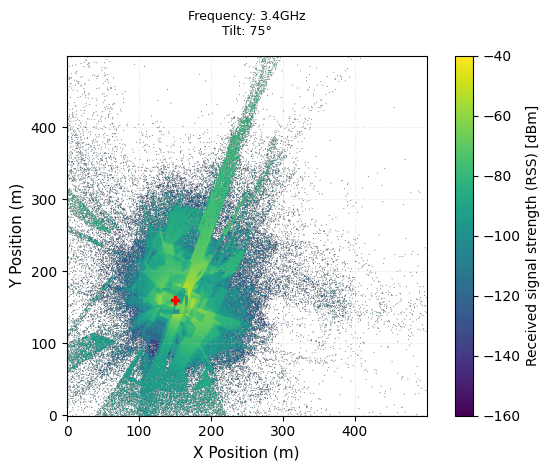

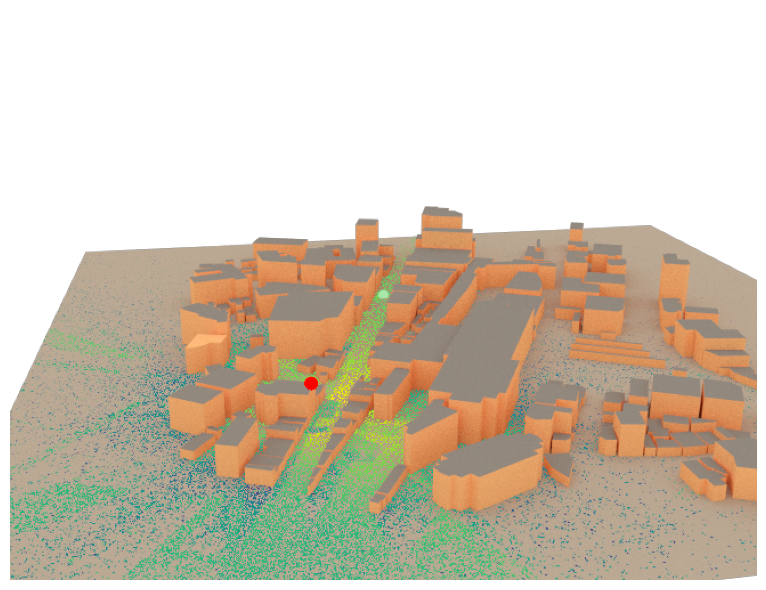

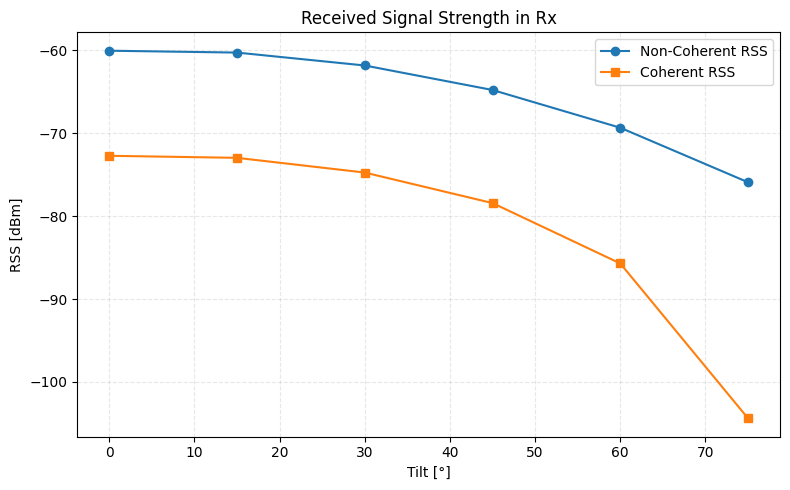

In [1]:
# Import libraries
import numpy as np
from sionna.rt import load_scene, ITURadioMaterial, Transmitter, Receiver, PlanarArray, RadioMapSolver, PathSolver, Camera
import matplotlib.pyplot as plt
import pandas as pd
import os

# Import scene from blender mitsuba export (.xml)
scene = load_scene("blender-assets/omori-station.xml")

# Check objects in the scene
print("Check Scene Objects:")
print(f"Objects in scene: {list(scene.objects.keys())}")
print(f"Radio Materials in scene: {list(scene.radio_materials.keys())}")

# Add array for both Tx and Rx to scene
scene.tx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",
                             polarization="V")

scene.rx_array = PlanarArray(num_rows=1, 
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

# Add frequency to scene
carrier_freq = 3.4e9 # In Hz
scene.frequency = carrier_freq

# Deploy Tx and Rx location

# Helper function to sync transmitter azimuth 0 degree with scene 0 degree
def compass_orientation(azimuth_deg, tilt_deg=0, roll_deg=0):

    # Sionna by default implement 0 degree Tx azimuth at X+ axis, -90 to achieve 0 degree at Y+ axis (North)
    sionna_azimuth = (90 - azimuth_deg) % 360

    # return radian
    return [
        float(np.deg2rad(sionna_azimuth)),
        float(np.deg2rad(tilt_deg)),
        float(np.deg2rad(roll_deg))
    ]

# Deploy Tx
tx_azimuth_deg = 45
tx_tilt_deg = 0

tx = Transmitter(
    "tx",
    position = [-100, -90, 18], # x, y, z (location and height, in meter)
    orientation=compass_orientation(azimuth_deg=tx_azimuth_deg,tilt_deg=tx_tilt_deg), 
    power_dbm=18
)

tx_power_dbm = tx.power_dbm[0]

# Deploy Rx
rx_azimuth_deg = 0
rx_tilt_deg = 0

rx = Receiver(
    "rx",
    [-30, 90, 1.5],
    orientation=[
        float(np.deg2rad(rx_azimuth_deg)), float(np.deg2rad(rx_tilt_deg)), 0.0]
)

# Point Rx to face Tx direction
rx.look_at(tx.position)

# Add Tx and Rx to the scene
scene.add(tx)
scene.add(rx)

# Solve radio map and paths - for every tilt (every 15 degree)

# Define empty list
rss_list_noncoherent = []
rss_list_coherent = []
tilt_list = []

# Define range of down tilt to test
tx_tilt_deg = range(0, 90, 15)

for i, tilt in enumerate(tx_tilt_deg):

    print(f"tx_tilt_deg = {tilt}°")

    # Update Tx tilt
    tx.orientation = compass_orientation(azimuth_deg=tx_azimuth_deg, tilt_deg=tilt)

    # Solve radio map
    rm_solver = RadioMapSolver()

    rm = rm_solver(
        scene,
        max_depth=10,
        samples_per_tx=10**7,
        cell_size=(1, 1),
        center=[0, 0, 0],
        size=[500, 500],
        orientation=[0, 0, 0]
    )

    # Plot 2D Radio map
    plt.figure(figsize=(8, 10))

    rm.show(metric="rss")

    plt.title(
        f"Frequency: {carrier_freq/1e9}GHz\nTilt: {tilt}°",
        fontsize=9,
        pad=15
    )
    plt.xlabel("X Position (m)", fontsize=11)
    plt.ylabel("Y Position (m)", fontsize=11)
    plt.clim(-160, -40)
    plt.grid(
        alpha=0.2,
        linestyle="--"
    )
    plt.tight_layout()
    plt.show()

    # Plot 3D radio map
    cam = Camera(
    position=(-140, -500, 200),
    look_at=rx.position
    )

    scene.render(
        camera=cam,
        radio_map=rm
    )

    # Solve paths
    p_solver = PathSolver()

    paths = p_solver(
        scene,
        max_depth=10,
        samples_per_src=10**6
    )

    # Extract path coefficients (a function return 2 components: a_real, a_imag)
    a_real, a_imag = paths.a
    a_real = a_real.numpy()
    a_imag = a_imag.numpy()

    # Reconstruct complex channel coefficients in real and imaginary form
    a = a_real + 1j * a_imag

  
    # Restructure multipath properties into array (in a list)
    num_paths = a.shape[-1]
    path_data = []

    for i in range(num_paths):

        # Get channel coefficient (real + imaginary) one by one
        a_coeff = a[0, 0, 0, 0, i]

        # Extract real and imaginary components
        real_coeff = np.real(a_coeff)
        imag_coeff = np.imag(a_coeff)

        # Magnitude and phase
        magnitude = np.abs(a_coeff) 
        phase_rad = np.angle(a_coeff) 

        # Channel Gain
        channel_path_gain = magnitude**2
        channel_path_gain_db = 10*np.log10(channel_path_gain)

        path_data.append({
            "path_id": i,

            "real_coeff": float(real_coeff),
            "imag_coeff": float(imag_coeff),

            "magnitude": float(magnitude),
            "phase_rad": float(phase_rad),
            "phase_deg": float(np.degrees(phase_rad)),

            "channel_path_gain": float(channel_path_gain),
            "channel_path_gain_db": float(channel_path_gain_db),
        })

    # Put array in Dataframe
    df_paths = pd.DataFrame(path_data)

    # Calculate Received Signal Strength (RSS) at Receivers 

    # Non Coherent Case (Just a sum of power in Rx)
    total_channel_path_gain = 10*np.log10(df_paths['channel_path_gain'].sum())
    rss_non_coherent = tx_power_dbm+total_channel_path_gain

    # Coherent Case (Consider constructive & destructive effect caused by phase delay in Rx)
    total_real = df_paths['real_coeff'].sum()
    total_imag = df_paths['imag_coeff'].sum()
    total_magnitude = np.sqrt(total_real**2 + total_imag**2)
    total_channel_path_gain = 10*np.log10(total_magnitude**2)
    rss_coherent = tx_power_dbm+total_channel_path_gain

    # Save result in a list
    tilt_list.append(tilt)
    rss_list_noncoherent.append(rss_non_coherent)
    rss_list_coherent.append(rss_coherent)


# Plot RSS (Coherent vs Non-Coherent) line chart
plt.figure(figsize=(8, 5))

plt.plot(
    tilt_list,
    rss_list_noncoherent,
    marker='o',
    label='Non-Coherent RSS'
)

plt.plot(
    tilt_list,
    rss_list_coherent,
    marker='s',
    label='Coherent RSS'
)

plt.legend()

plt.xlabel("Tilt [°]")
plt.ylabel("RSS [dBm]")
plt.title("Received Signal Strength in Rx")
plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# # Optional - Scene Preview
# scene.preview()

# # Optional - Scene Preview (Radio Map)
# rm_solver = RadioMapSolver()

# rm = rm_solver(
#         scene,
#         max_depth=10, # Number of maximum interation allowed per paths
#         samples_per_tx=10**7, # Number of rays launch in transmitter
#         cell_size=(1, 1),
#         center=[0, 0, 0],
#         size=[500, 500], # Size of area to simulate (meter)
#         orientation=[0, 0, 0]
#     )

# scene.preview(
#     radio_map=rm,

#     rm_metric="rss",
#     rm_db_scale=True,

#     rm_vmax = -40,
#     rm_vmin = -160,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )

# # Optional - Scene Preview (Paths)
# p_solver = PathSolver()

# paths = p_solver(
#     scene,
#     max_depth=10,
#     samples_per_src=10**6
# )

# scene.preview(
#     paths=paths,

#     show_devices=True,
#     show_orientations=True,

#     point_picker=False
# )